# Telco Customer Churn

**Business Problem:**
You are a Data Scientist at a telecommunications company. The company wants to identify customers who are likely to churn so that the retention team can proactively engage with them.
Using the provided Telco Customer Churn dataset, build an end-to-end machine learning solution to predict customer churn.
Dataset: IBM Telco Customer Churn Dataset Target Variable: Churn (Yes / No)

**Objective:** identify customers likely to churn so the retention team can intervene proactively. The target is `Churn` (`Yes`/`No`).

## 1. Data understanding and preparation

`TotalCharges` is imported as text because some new customers have blank values.
 `customerID` is an identifier and is excluded. Cleaning, feature engineering, imputation, and encoding are placed inside a scikit-learn pipeline fitted only on the training split to prevent leakage.

In [ ]:
# Import the libraries used in this project
from pathlib import Path
import sys
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Find the project folder and load the data
ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))
from churn_features import add_features

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
DATA_PATH = ROOT / "data" / "TelcoCustomerChurn.csv"
df = pd.read_csv(DATA_PATH)

print("Number of rows and columns:", df.shape)
display(df.head())
display(df.dtypes.to_frame("data type"))

Number of rows and columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


,data type
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


In [87]:
print("Duplicate rows:", df.duplicated().sum())
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))
print("Blank TotalCharges:", (df["TotalCharges"].astype(str).str.strip() == "").sum())
print("Target counts:")
display(df["Churn"].value_counts().to_frame("count").assign(percent=lambda x: 100 * x["count"] / len(df)))

df["Churn"] = df["Churn"].str.strip()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].replace("", pd.NA), errors="coerce")
X = df.drop(columns="Churn")
y = df["Churn"]

# Split the data into two parts.
# 70% is used to train the model.
# 30% is used to test the model on unseen customers.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training data rows:", len(X_train))
print("Testing data rows:", len(X_test))
print(X_test.to_json('test_data.json', orient='records'))
print("Training percentage:", round(len(X_train) / len(df) * 100, 1), "%")
print("Testing percentage:", round(len(X_test) / len(df) * 100, 1), "%")

Duplicate rows: 0
Missing values:


,missing
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Blank TotalCharges: 11
Target counts:


,count,percent
Churn,,
No,5174,73.463013
Yes,1869,26.536987


Training data rows: 4930
Testing data rows: 2113
None
Training percentage: 70.0 %
Testing percentage: 30.0 %


## 2. Exploratory data analysis

The plots below cover the target, customer contracts and services, and numerical behaviour.

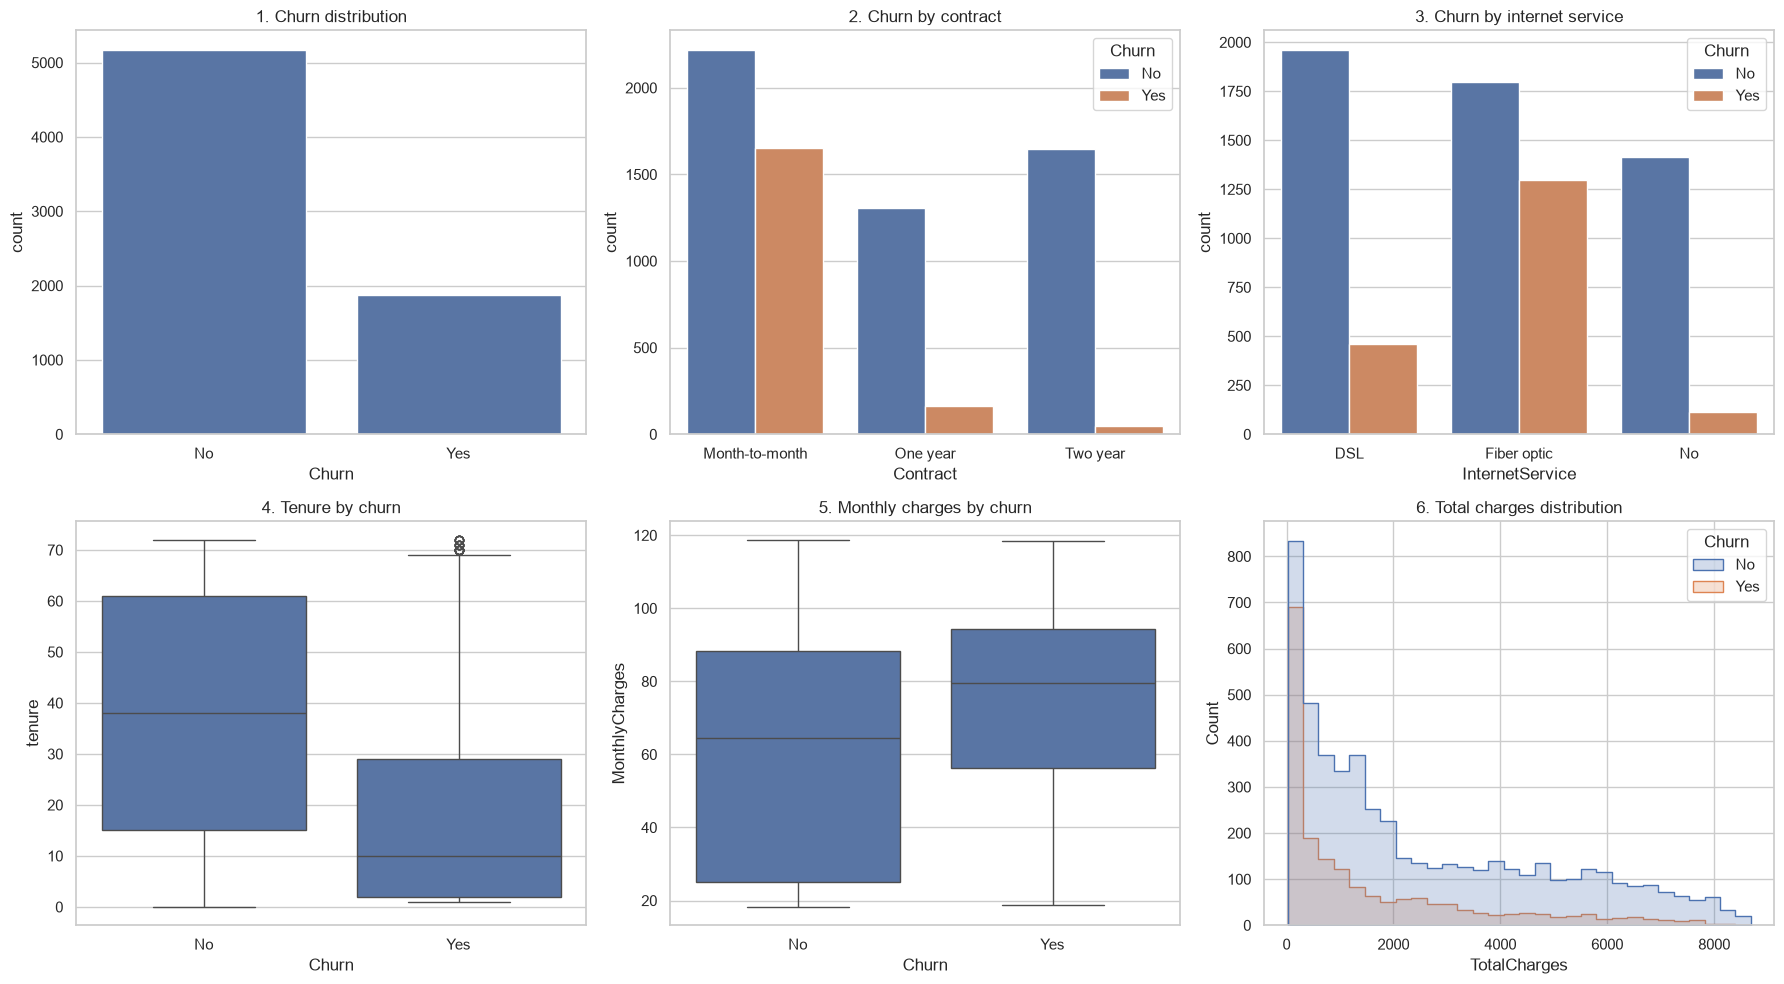

In [88]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.countplot(data=df, x="Churn", ax=axes[0, 0]); axes[0, 0].set_title("1. Churn distribution")
sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0, 1]); axes[0, 1].set_title("2. Churn by contract")
sns.countplot(data=df, x="InternetService", hue="Churn", ax=axes[0, 2]); axes[0, 2].set_title("3. Churn by internet service")
sns.boxplot(data=df, x="Churn", y="tenure", ax=axes[1, 0]); axes[1, 0].set_title("4. Tenure by churn")
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1, 1]); axes[1, 1].set_title("5. Monthly charges by churn")
sns.histplot(data=df, x="TotalCharges", hue="Churn", bins=30, element="step", ax=axes[1, 2]); axes[1, 2].set_title("6. Total charges distribution")
plt.tight_layout()
plt.show()

**Insights:** 
month-to-month customers generally churn more than customers on longer contracts; 
fiber optic customers show elevated churn; 
churners tend to have shorter tenure and higher monthly charges. 
Total charges should be interpreted together with tenure because they accumulate over time.

## 3. Feature engineering

`add_features` creates `tenure_years`, `avg_monthly_charge`, and `service_count`. 
These capture customer lifecycle, realized spend, and product engagement using information available at prediction time.

In [89]:
# Create the three new features and check the result
engineered_data = add_features(df.drop(columns="Churn"))
new_features = ["tenure_years", "avg_monthly_charge", "service_count"]
display(engineered_data[["tenure", "TotalCharges"] + new_features].head())

# These are the numerical columns after feature engineering
numeric_features = [
    "SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges",
    "tenure_years", "avg_monthly_charge", "service_count"
]

# All remaining customer columns are categorical columns
categorical_features = [
    column for column in X.columns
    if column not in numeric_features and column != "customerID"
]

# Fill missing numbers with the median value
number_steps = Pipeline([
    ("fill_missing_numbers", SimpleImputer(strategy="median"))
])

# Fill missing categories and convert categories to numbers
category_steps = Pipeline([
    ("fill_missing_categories", SimpleImputer(strategy="most_frequent")),
    ("convert_categories_to_numbers", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the correct steps to each type of column
preprocessing_steps = ColumnTransformer([
    ("numbers", number_steps, numeric_features),
    ("categories", category_steps, categorical_features)
])

# Keep feature creation and preprocessing inside the model pipeline.
# This prevents information from the test data entering training.
def create_model(decision_tree):
    return Pipeline([
        ("create_features", FunctionTransformer(add_features, validate=False)),
        ("preprocess_data", preprocessing_steps),
        ("decision_tree", decision_tree)
    ])

,tenure,TotalCharges,tenure_years,avg_monthly_charge,service_count
0,1,29.85,0.083333,29.850000,1
1,34,1889.50,2.833333,55.573529,3
2,2,108.15,0.166667,54.075000,3
3,45,1840.75,3.750000,40.905556,3
4,2,151.65,0.166667,75.825000,1


## 4. Model Development and Model Evaluation

We compare two simple Decision Tree models. The first is a basic tree. The second is a smaller tree with `class_weight="balanced"`, which gives more attention to the smaller churn class. We choose the second model because finding churners is important for the retention team.

In [90]:
# Model 1: a basic decision tree
basic_tree = DecisionTreeClassifier(random_state=42)
basic_model = create_model(basic_tree)
basic_model.fit(X_train, y_train)
basic_predictions = basic_model.predict(X_test)

# Model 2: a smaller balanced tree
# max_depth and min_samples_leaf help reduce overfitting.
balanced_tree = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)
balanced_model = create_model(balanced_tree)
balanced_model.fit(X_train, y_train)
balanced_predictions = balanced_model.predict(X_test)

# Compare the two models using the four required measures
def calculate_scores(actual_values, predicted_values):
    return {
        "accuracy": accuracy_score(actual_values, predicted_values),
        "precision": precision_score(actual_values, predicted_values, pos_label="Yes"),
        "recall": recall_score(actual_values, predicted_values, pos_label="Yes"),
        "f1": f1_score(actual_values, predicted_values, pos_label="Yes")
    }

basic_scores = calculate_scores(y_test, basic_predictions)
balanced_scores = calculate_scores(y_test, balanced_predictions)
comparison_df = pd.DataFrame([
    {"model": "Basic tree", **basic_scores},
    {"model": "Balanced smaller tree", **balanced_scores}
])
display(comparison_df)

,model,accuracy,precision,recall,f1
0,Basic tree,0.721723,0.475588,0.468806,0.472172
1,Balanced smaller tree,0.742073,0.509368,0.775401,0.614841


For retention outreach, recall is generally the priority: a false negative is a customer who churns without intervention, while a false positive is usually a lower-cost outreach opportunity. Precision still matters when incentives or contact capacity are expensive.

Selected model: Balanced smaller tree
Accuracy: 0.7420728821580691
Precision: 0.509367681498829
Recall: 0.7754010695187166
F1 score: 0.6148409893992933

Detailed classification report:
              precision    recall  f1-score   support

          No       0.90      0.73      0.81      1552
         Yes       0.51      0.78      0.61       561

    accuracy                           0.74      2113
   macro avg       0.70      0.75      0.71      2113
weighted avg       0.80      0.74      0.76      2113



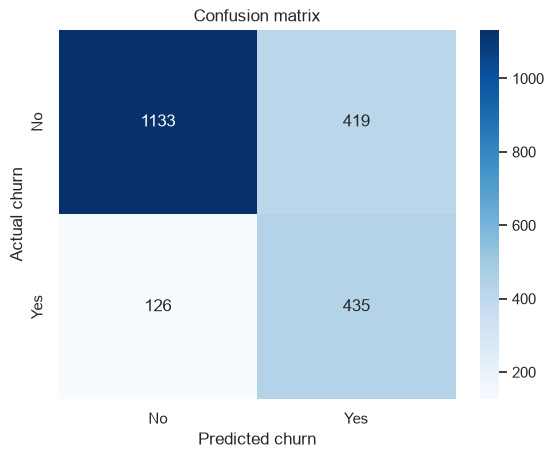

In [91]:
# Use the balanced smaller tree as the final model.
# It is better for this problem because it pays more attention to churners.
final_model = balanced_model
final_predictions = balanced_predictions
selected_model_name = "Balanced smaller tree"

print("Selected model:", selected_model_name)
print("Accuracy:", accuracy_score(y_test, final_predictions))
print("Precision:", precision_score(y_test, final_predictions, pos_label="Yes"))
print("Recall:", recall_score(y_test, final_predictions, pos_label="Yes"))
print("F1 score:", f1_score(y_test, final_predictions, pos_label="Yes"))

print("\nDetailed classification report:")
print(classification_report(y_test, final_predictions))

# A confusion matrix shows correct and incorrect predictions.
matrix = confusion_matrix(y_test, final_predictions)
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)
plt.xlabel("Predicted churn")
plt.ylabel("Actual churn")
plt.title("Confusion matrix")
plt.show()

## 5. Model interpretation

Feature importance shows which encoded variables the tree uses most. This is predictive importance, not proof of causality. The limited-depth tree plot keeps the decision rules readable.

,importance
categories__Contract_Month-to-month,0.496682
categories__InternetService_Fiber optic,0.087179
numbers__tenure_years,0.068904
numbers__MonthlyCharges,0.067758
numbers__tenure,0.051122
numbers__avg_monthly_charge,0.036618
numbers__TotalCharges,0.035181
categories__OnlineSecurity_No,0.035106
categories__TechSupport_No,0.025155
categories__PaymentMethod_Electronic check,0.023859


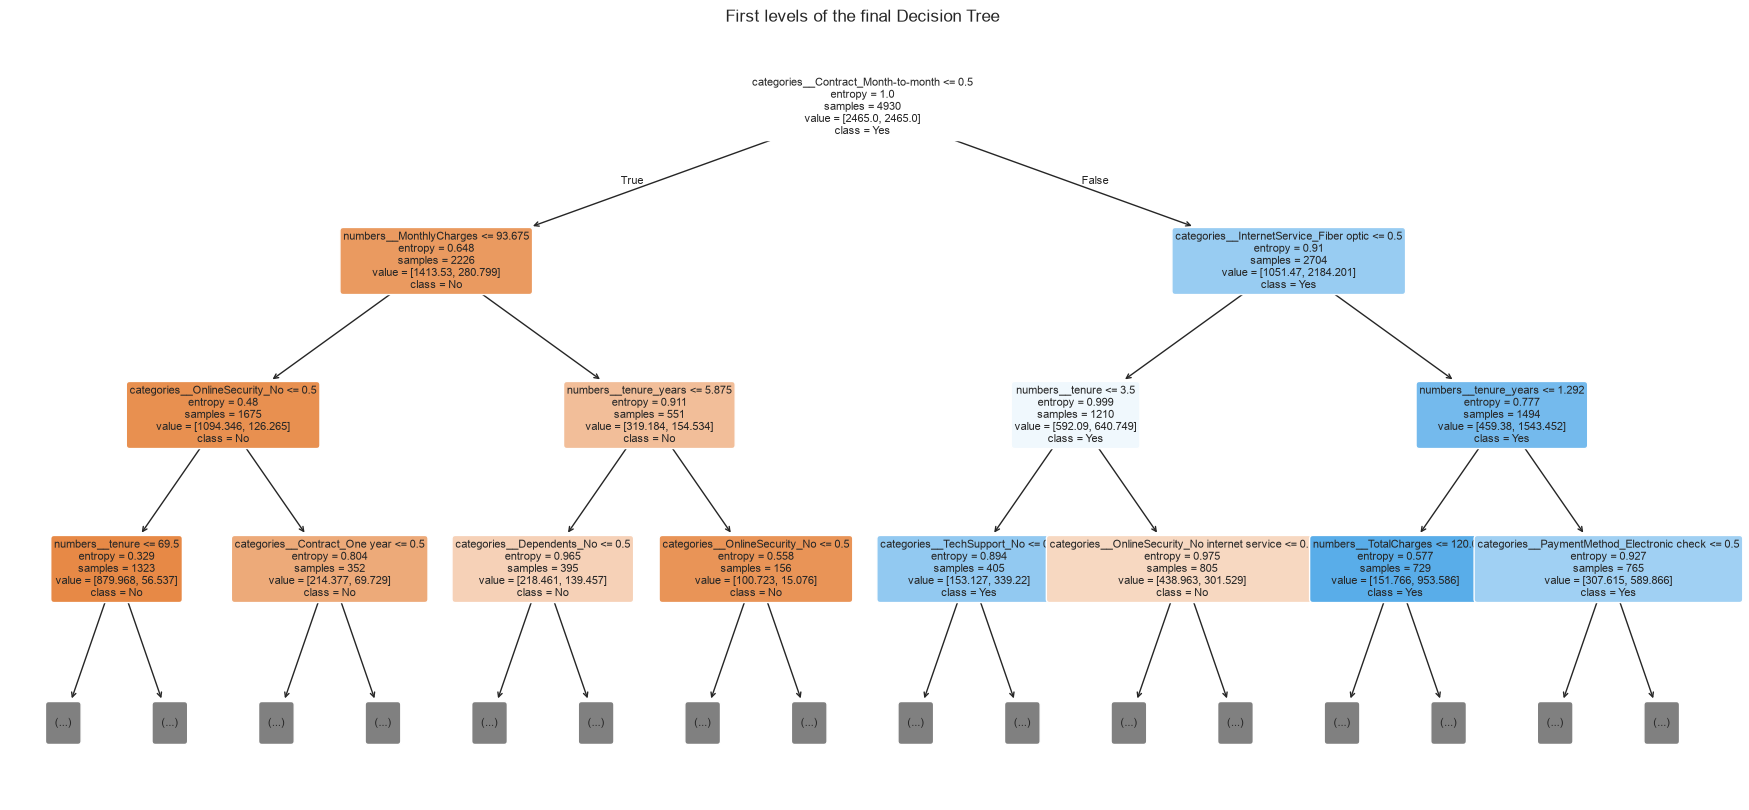

In [92]:
# Get the names of the columns after one-hot encoding
preprocessor = final_model.named_steps["preprocess_data"]
tree = final_model.named_steps["decision_tree"]
feature_names = preprocessor.get_feature_names_out()

# Show the features used most often by the tree
feature_importance = pd.Series(tree.feature_importances_, index=feature_names)
feature_importance = feature_importance.sort_values(ascending=False)
display(feature_importance.head(15).to_frame("importance"))

# Draw the first few levels so the decision rules are easy to read
plt.figure(figsize=(22, 10))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=["No", "Yes"],
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("First levels of the final Decision Tree")
plt.show()

## 6. Save the reusable model

The exported object includes feature engineering, imputation, one-hot encoding, and the classifier, so it can process unseen JSON rows consistently.

In [93]:
# Save the complete pipeline.
# It contains feature creation, preprocessing, and the decision tree.
MODEL_PATH = ROOT / "model" / "churn_model.pkl"
MODEL_PATH.parent.mkdir(exist_ok=True)
joblib.dump(final_model, MODEL_PATH)
print("Model saved to:", MODEL_PATH)

# Test that the saved model can predict a new row
print("Example prediction:", final_model.predict(X_test.head(1)))
print("Example probabilities:", final_model.predict_proba(X_test.head(1)))

Model saved to: c:\Users\sarwadekumar\OneDrive - Nagarro\Desktop\NAGP2026\Home Assignment - Technology Band III\customer_churn_project\model\churn_model.pkl
Example prediction: ['Yes']
Example probabilities: [[0.37179858 0.62820142]]
